In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [111]:
distance_unc = 0.5

In [112]:
df = pd.read_csv("data.csv")
df

,configuration,half_distance,exit_lower,exit_upper,return_lower,return_upper
0,0,155.5,12.6,13.8,21.0,22.6
1,1,175.5,11.8,13.4,21.6,23.0
2,2,195.5,11.0,12.6,22.0,24.8
3,3,215.5,10.2,11.6,23.0,24.8
4,4,235.5,7.8,10.6,23.2,24.6
5,5,255.5,7.2,10.0,22.8,25.2
6,6,275.5,6.0,8.0,23.6,25.6
7,7,295.5,5.6,7.2,24.2,26.4
8,8,315.5,3.0,5.2,23.0,25.2


In [113]:
df

,configuration,half_distance,exit_lower,exit_upper,return_lower,return_upper
0,0,155.5,12.6,13.8,21.0,22.6
1,1,175.5,11.8,13.4,21.6,23.0
2,2,195.5,11.0,12.6,22.0,24.8
3,3,215.5,10.2,11.6,23.0,24.8
4,4,235.5,7.8,10.6,23.2,24.6
5,5,255.5,7.2,10.0,22.8,25.2
6,6,275.5,6.0,8.0,23.6,25.6
7,7,295.5,5.6,7.2,24.2,26.4
8,8,315.5,3.0,5.2,23.0,25.2


In [114]:
df["exit_unc"] = (df["exit_upper"] - df["exit_lower"]) / 2
df["exit"] = (df["exit_upper"] + df["exit_lower"]) / 2
df["return_unc"] = (df["return_upper"] - df["return_lower"]) / 2
df["return"] = (df["return_upper"] + df["return_lower"]) / 2
df["time"] = df["return"] - df["exit"]

In [115]:
df

,configuration,half_distance,exit_lower,exit_upper,return_lower,return_upper,exit_unc,exit,return_unc,return,time
0,0,155.5,12.6,13.8,21.0,22.6,0.6,13.2,0.8,21.8,8.6
1,1,175.5,11.8,13.4,21.6,23.0,0.8,12.6,0.7,22.3,9.7
2,2,195.5,11.0,12.6,22.0,24.8,0.8,11.8,1.4,23.4,11.6
3,3,215.5,10.2,11.6,23.0,24.8,0.7,10.9,0.9,23.9,13.0
4,4,235.5,7.8,10.6,23.2,24.6,1.4,9.2,0.7,23.9,14.7
5,5,255.5,7.2,10.0,22.8,25.2,1.4,8.6,1.2,24.0,15.4
6,6,275.5,6.0,8.0,23.6,25.6,1.0,7.0,1.0,24.6,17.6
7,7,295.5,5.6,7.2,24.2,26.4,0.8,6.4,1.1,25.3,18.9
8,8,315.5,3.0,5.2,23.0,25.2,1.1,4.1,1.1,24.1,20.0


# Pointwise Evaluation


$$
c(d, t) = \frac{2d}{t}
$$

$$
\begin{align}
\delta c = \sqrt{
    (\partial_d c \cdot \delta d)^2 + (\partial_t c \cdot \delta c)^2
}  \\
\delta c = \sqrt{
    \left (\left (\frac{2}{t} \right ) \delta d \right)^2 + \left (\left (-\frac{2d}{t^2} \right) \delta t \right)^2
}
\end{align}
$$


$$
t(e, r) = r - e
$$

$$
\delta t = \sqrt{
    (1 \delta r)^2 + (-1 \delta e)^2
} = \sqrt{\delta r ^2 + \delta e ^2}
$$


In [116]:
def delta_c(d: float, t: float, delta_d: float, delta_t: float) -> float:
    return np.sqrt(((2 / t) * delta_d) ** 2 + ((-2 * d / (t**2)) * delta_t) ** 2)


def delta_t(e: float, r: float, delta_e: float, delta_r: float) -> float:
    return np.sqrt((delta_e) ** 2 + (delta_r) ** 2)


def c(d: float, t: float) -> float:
    return 2 * d / t

In [117]:
df["time"] = df["return"] - df["exit"]
df["time_unc"] = delta_t(
    df["return_unc"], df["exit_unc"], df["return_unc"], df["exit_unc"]
)

In [118]:
df["half_distance_unc"] = 0.5

In [119]:
df["speed"] = c(df["half_distance"], df["time"])
df["speed_unc"] = delta_c(
    df["half_distance"], df["time"], df["half_distance_unc"], df["time_unc"]
)

In [120]:
df[["speed", "speed_unc"]]  # cm / ns, cm / ns

,speed,speed_unc
0,36.162791,4.206583
1,36.185567,3.966885
2,33.706897,4.686201
3,33.153846,2.908802
4,32.040816,3.412366
5,33.181818,3.973534
6,31.306818,2.516240
7,31.269841,2.250970
8,31.550000,2.454523


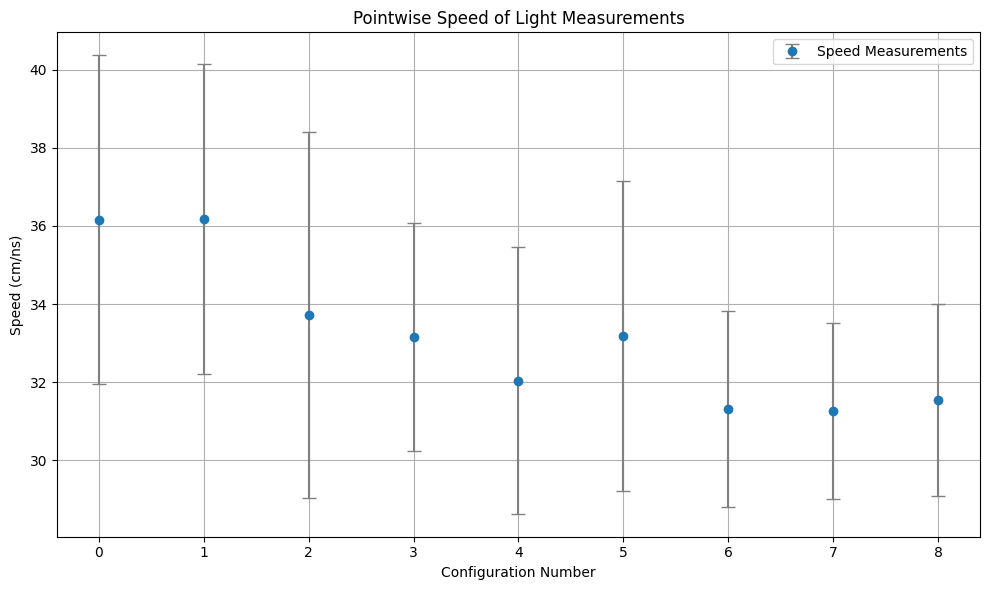

In [129]:
plt.figure(figsize=(10, 6))
plt.errorbar(
    df.index,
    df["speed"],
    yerr=df["speed_unc"],
    fmt="o",
    capsize=5,
    ecolor="gray",
    label="Speed Measurements",
)
plt.xlabel("Configuration Number")
plt.ylabel("Speed (cm/ns)")
plt.title("Pointwise Speed of Light Measurements")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("speed_measurements.png", dpi=300)
plt.show()


In [121]:
print(df[["speed", "speed_unc"]].to_markdown(index=True))

|    |   speed |   speed_unc |
|---:|--------:|------------:|
|  0 | 36.1628 |     4.20658 |
|  1 | 36.1856 |     3.96688 |
|  2 | 33.7069 |     4.6862  |
|  3 | 33.1538 |     2.9088  |
|  4 | 32.0408 |     3.41237 |
|  5 | 33.1818 |     3.97353 |
|  6 | 31.3068 |     2.51624 |
|  7 | 31.2698 |     2.25097 |
|  8 | 31.55   |     2.45452 |


In [122]:
df["speed"].describe()

count     9.000000
mean     33.173155
std       1.914436
min      31.269841
25%      31.550000
50%      33.153846
75%      33.706897
max      36.185567
Name: speed, dtype: float64

In [123]:
df["speed"].std() / np.sqrt(len(df))

np.float64(0.6381452611402195)

In [124]:
# Manually computed standard deviation. NOTE: n - 1 as factor.
mean_speed = df["speed"].mean()
squared_diff_sum = ((df["speed"] - mean_speed) ** 2).sum()
manual_std = np.sqrt(squared_diff_sum / (len(df) - 1))
manual_std

np.float64(1.9144357834206587)

In [125]:
np.sqrt(0.6**2 + 0.8**2)

np.float64(1.0)

In [ ]:
import math

result = math.sqrt(((2 / 8.6) * 0.5) ** 2 + ((2 * 155.5) / (8.6**2) * 1) ** 2)

print(result)

4.206583072334821
